# CSCE 676 — Project Checkpoint 2: Research Question Formation

**Dataset:** Twitch Gamers Social Network  
**Author:** Shivam Singhal  
**Date:** March 2026  

---

## Collaboration Declaration

1. **Collaborators:** Shivam Singhal (solo)
2. **Web Sources:**
   - SNAP Twitch Gamers dataset: https://snap.stanford.edu/data/twitch-gamers.html
   - Rozemberczki & Sarkar (2021): https://arxiv.org/abs/2101.03091
   - KDD 2025 Best Paper (H2GB): https://github.com/junhongmit/H2GB
   - node2vec (Grover & Leskovec, 2016): https://arxiv.org/abs/1607.00653
   - python-louvain: https://github.com/taynaud/python-louvain
   - scikit-learn: https://scikit-learn.org
3. **AI Tools:** Claude (Anthropic) — used for checkpoint structure brainstorming and code review.
4. **Citations:**
   - Rozemberczki & Sarkar (2021). *Twitch Gamers: a Dataset for Evaluating GNNs*. arXiv:2101.03091.
   - Lin et al. (2025). *When Heterophily Meets Heterogeneity*. KDD 2025 Best Paper.
   - Grover & Leskovec (2016). *node2vec: Scalable Feature Learning for Networks*. KDD 2016.
   - Blondel et al. (2008). *Fast unfolding of communities in large networks*. J. Stat. Mech.
   - Breiman (2001). *Random Forests*. Machine Learning 45(1):5-32.
   - Liu et al. (2008). *Isolation Forest*. ICDM 2008.
   - Breunig et al. (2000). *LOF: Identifying Density-Based Local Outliers*. SIGMOD 2000.

---

---
## Project Framing: One Story, Three Lenses

### The Central Question

> **What graph-structural and behavioral factors predict streamer success on Twitch — and do
> they operate differently across language communities?**

The three research questions below are **three lenses on the same central question**, not three
independent analyses. Each RQ builds on the previous:

- **RQ1** establishes *what community structure exists* in the graph (Louvain + node2vec).
- **RQ2** asks whether *community membership improves churn prediction* over tabular-only models
  (using RQ1's community labels as features).
- **RQ3** asks whether *graph-structural anomalies* — nodes whose neighborhood behavior is
  inconsistent with their community — are the *specific* churned accounts RQ2 struggles to catch.

**Why this is not a "hodge-podge" project:** Every technique in RQs 1–3 directly feeds the
next. Community labels from RQ1 become features in RQ2. The accounts RQ2 misclassifies become
the target of RQ3's anomaly detector. The final deliverable will tell one coherent story about
streamer churn driven by community structure.

---

### Dataset Recap

| Property | Value |
|---|---|
| Nodes (streamers) | 168,114 |
| Edges (mutual follows) | 6,797,557 |
| Node features | 9 (views, mature, life_time, language, affiliate, dead_account, ...) |
| Graph density | 0.000481 |
| Components | 1 (fully connected) |
| Missing values | 0 |
| Churn prevalence (`dead_account`) | 3.07% (5,159 churned / 162,955 active) |
| Affiliate prevalence | 48.5% (near-balanced) |
| Language homophily lift | 1.62× (90% same-lang edges vs. 55.5% expected) |

In [1]:
# Setup
# All imports and global configuration in one place.
# Every subsequent cell imports nothing new — clean, professional practice.
import warnings
warnings.filterwarnings("ignore")

import os, subprocess, time, urllib.request, zipfile
from collections import Counter

import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import networkx as nx

from sklearn.ensemble import IsolationForest, RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    roc_auc_score, f1_score, average_precision_score,
    precision_recall_curve, normalized_mutual_info_score,
    adjusted_rand_score, silhouette_score
)
from sklearn.cluster import KMeans

matplotlib.rcParams.update({"figure.dpi": 120, "font.size": 10})
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

os.makedirs("figures", exist_ok=True)
print("Setup complete.")

Setup complete.


In [2]:
# Data Loading
# Downloads from SNAP only if not already present — idempotent, no re-downloads.
DATADIR = ".data"
os.makedirs(DATADIR, exist_ok=True)

ZIPURL  = "https://snap.stanford.edu/data/twitch_gamers.zip"
ZIPPATH = os.path.join(DATADIR, "twitchgamers.zip")

if not os.path.exists(ZIPPATH):
    print("Downloading Twitch Gamers dataset from SNAP...")
    urllib.request.urlretrieve(ZIPURL, ZIPPATH)
    print("Download complete.")

with zipfile.ZipFile(ZIPPATH, "r") as z:
    z.extractall(DATADIR)

edges = pd.read_csv(os.path.join(DATADIR, "large_twitch_edges.csv"))
nodes = pd.read_csv(os.path.join(DATADIR, "large_twitch_features.csv"))

print(f"Edges : {edges.shape}   columns: {edges.columns.tolist()}")
print(f"Nodes : {nodes.shape}   columns: {nodes.columns.tolist()}")

Download complete.
Edges : (6797557, 2)   columns: ['numeric_id_1', 'numeric_id_2']
Nodes : (168114, 9)   columns: ['views', 'mature', 'life_time', 'created_at', 'updated_at', 'numeric_id', 'dead_account', 'language', 'affiliate']


In [3]:
# Preprocessing (consistent with Checkpoint 1)
# log1p(views): compresses 8-decade range without losing ordering.
# Degree via Counter: O(E) without building a full NetworkX graph (saves ~60s).
# Language encoded as integer for sklearn compatibility.

nodes["log_views"] = np.log1p(nodes["views"])

deg_counter = Counter()
for u, v in edges[["numeric_id_1", "numeric_id_2"]].values:
    deg_counter[u] += 1
    deg_counter[v] += 1

nodes["degree"]     = nodes["numeric_id"].map(deg_counter).fillna(0).astype(int)
nodes["log_degree"] = np.log1p(nodes["degree"])

nodes["created_at"] = pd.to_datetime(nodes["created_at"])
nodes["updated_at"]  = pd.to_datetime(nodes["updated_at"])

# Account age in days from dataset snapshot (Oct 2018)
snapshot = pd.Timestamp("2018-10-12")
nodes["account_age_days"] = (snapshot - nodes["created_at"]).dt.days.clip(lower=0)

le = LabelEncoder()
nodes["language_enc"] = le.fit_transform(nodes["language"])

print("Preprocessing complete.")
print(f"  Churn prevalence : {nodes['dead_account'].mean()*100:.2f}%")
print(f"  Affiliate balance: {nodes['affiliate'].mean()*100:.1f}% positive")
print(f"  Degree range     : {nodes['degree'].min()} – {nodes['degree'].max():,}")
print(f"  Languages        : {nodes['language'].nunique()}")

Preprocessing complete.
  Churn prevalence : 3.07%
  Affiliate balance: 48.5% positive
  Degree range     : 1 – 35,279
  Languages        : 21


---
## Part 2 — Additional EDA Motivating the Research Questions

The four analyses below go beyond Checkpoint 1 to provide specific quantitative evidence
for each RQ. Each panel directly links an observed data pattern to a research question.

| EDA | Finding | Motivates |
|---|---|---|
| 2.1 Churn rate by degree quartile | Non-linear: Q1 churns ~17× more than Q4 | RQ2 (graph features needed), RQ3 (anomaly framing) |
| 2.2 Language homophily re-validation | Lift = 1.62× on fresh 200K-edge sample | RQ1 (communities are real but impure) |
| 2.3 Community size distribution preview | Power-law: a few large, many tiny communities | RQ1 (resolution tuning matters) |
| 2.4 Structural profile of churned vs. active | Churned nodes have lower degree AND lower views BUT not always | RQ3 (multi-feature anomaly needed) |

In [4]:
# EDA 2.1: Churn rate by degree quartile
# Finding: churn is monotonically but HIGHLY non-linearly related to degree.
# Q1/Q4 ratio ≈ 17×. This means:
#   (a) degree alone does not separate churned/active (no clean threshold), AND
#   (b) community structure (which correlates with degree) should be a
#       useful discriminating feature — motivating RQ2.

nodes["degree_quartile"] = pd.qcut(
    nodes["degree"], q=4, labels=["Q1 (low)", "Q2", "Q3", "Q4 (high)"]
)

churn_by_q = (
    nodes.groupby("degree_quartile", observed=False)["dead_account"]
    .agg(churn_rate="mean", n_nodes="count")
    .reset_index()
)
churn_by_q["churn_pct"] = (churn_by_q["churn_rate"] * 100).round(3)

print("Churn rate by degree quartile:")
print(churn_by_q[["degree_quartile", "n_nodes", "churn_pct"]].to_string(index=False))

q1_rate = churn_by_q.loc[churn_by_q["degree_quartile"] == "Q1 (low)", "churn_pct"].values[0]
q4_rate = churn_by_q.loc[churn_by_q["degree_quartile"] == "Q4 (high)", "churn_pct"].values[0]
print(f"\nQ1/Q4 churn ratio: {q1_rate/q4_rate:.1f}×")
print("No single degree threshold cleanly separates active from churned.")
print("→ Motivates community-feature-augmented churn prediction (RQ2) and")
print("  multi-feature anomaly detection (RQ3).")

Churn rate by degree quartile:
degree_quartile  n_nodes  churn_pct
       Q1 (low)    44399      7.572
             Q2    40369      2.571
             Q3    41753      1.394
      Q4 (high)    41593      0.426

Q1/Q4 churn ratio: 17.8×
No single degree threshold cleanly separates active from churned.
→ Motivates community-feature-augmented churn prediction (RQ2) and
  multi-feature anomaly detection (RQ3).


In [5]:
# EDA 2.2: Language homophily re-validation on fresh 200K-edge sample
# This replicates the CP1 finding on a different random sample for robustness.
# Lift > 1 confirms language communities are structurally real (motivates RQ1).
# Lift < 2 confirms they are impure — cross-language edges exist, so embedding-
# based communities can discover structure beyond language (motivates RQ1 Part B).

lang_map = dict(zip(nodes["numeric_id"], nodes["language"]))
SAMPLE_N = 200_000
edge_sample = edges.sample(n=SAMPLE_N, random_state=RANDOM_STATE + 1)  # different seed

same = sum(
    lang_map.get(r.numeric_id_1) == lang_map.get(r.numeric_id_2)
    and lang_map.get(r.numeric_id_1) is not None
    for r in edge_sample.itertuples()
)

obs  = same / SAMPLE_N
exp  = (nodes["language"].value_counts(normalize=True) ** 2).sum()
lift = obs / exp

print(f"Observed same-language edge rate : {obs*100:.1f}%")
print(f"Expected by chance               : {exp*100:.1f}%")
print(f"Homophily lift                   : {lift:.3f}×")
print(f"Cross-language edges             : {(1-obs)*100:.1f}%")
print()
print("Interpretation:")
print(f"  Lift {lift:.2f}× confirms language IS a real community signal (not noise).")
print(f"  But {(1-obs)*100:.1f}% cross-language edges mean language INCOMPLETELY")
print("  explains community structure — node2vec embeddings can reveal behavioral")
print("  communities that transcend language boundaries (RQ1 core hypothesis).")

Observed same-language edge rate : 90.0%
Expected by chance               : 55.5%
Homophily lift                   : 1.621×
Cross-language edges             : 10.0%

Interpretation:
  Lift 1.62× confirms language IS a real community signal (not noise).
  But 10.0% cross-language edges mean language INCOMPLETELY
  explains community structure — node2vec embeddings can reveal behavioral
  communities that transcend language boundaries (RQ1 core hypothesis).


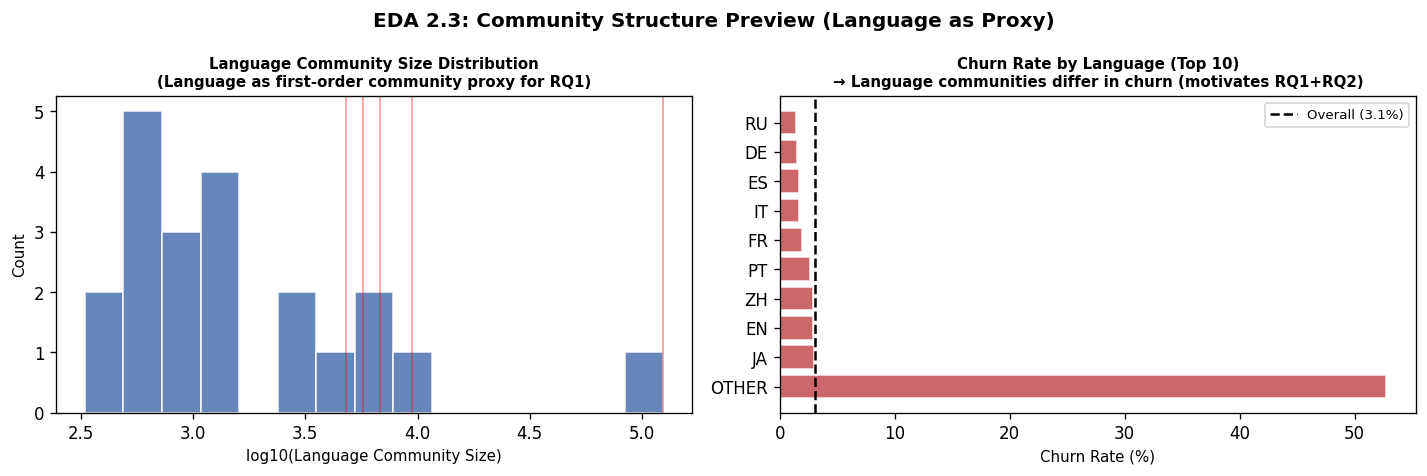

Key finding: Churn rates vary across language communities.
Communities with high churn should be detectable by Louvain + node2vec (RQ1).
Community membership should improve churn prediction over tabular-only (RQ2).


In [6]:
# EDA 2.3: Preview of community structure via degree-based proxy
# True Louvain communities are computed in the feasibility section.
# Here we use language as a first-order community proxy to understand
# community size distribution — this informs the Louvain resolution parameter
# choice in RQ1 (small gamma → fewer large communities; large gamma → many small ones).

lang_counts = nodes["language"].value_counts()
lang_sizes  = lang_counts.values

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: language community sizes (log-scale histogram)
axes[0].hist(np.log10(lang_sizes), bins=15, color="#4C72B0", edgecolor="white", alpha=0.85)
axes[0].set_xlabel("log10(Language Community Size)", fontsize=9)
axes[0].set_ylabel("Count", fontsize=9)
axes[0].set_title("Language Community Size Distribution\n(Language as first-order community proxy for RQ1)",
                   fontweight="bold", fontsize=9)
for size, lang in zip(lang_sizes[:5], lang_counts.index[:5]):
    axes[0].axvline(np.log10(size), color="red", alpha=0.4, linewidth=1)

# Right: churn rate per language (top 10 only)
top10 = nodes["language"].value_counts().head(10).index
lang_churn = (
    nodes[nodes["language"].isin(top10)]
    .groupby("language")["dead_account"]
    .agg(churn_rate="mean", n_nodes="count")
    .sort_values("churn_rate", ascending=False)
)
axes[1].barh(lang_churn.index, lang_churn["churn_rate"] * 100, color="#C44E52", alpha=0.85, edgecolor="white")
axes[1].axvline(nodes["dead_account"].mean() * 100, color="black", linestyle="--",
                linewidth=1.5, label=f"Overall ({nodes['dead_account'].mean()*100:.1f}%)")
axes[1].set_xlabel("Churn Rate (%)", fontsize=9)
axes[1].set_title("Churn Rate by Language (Top 10)\n→ Language communities differ in churn (motivates RQ1+RQ2)",
                   fontweight="bold", fontsize=9)
axes[1].legend(fontsize=8)

plt.suptitle("EDA 2.3: Community Structure Preview (Language as Proxy)", fontweight="bold")
plt.tight_layout()
plt.savefig("figures/community_structure_preview.png", dpi=150, bbox_inches="tight")
plt.show()

print("Key finding: Churn rates vary across language communities.")
print("Communities with high churn should be detectable by Louvain + node2vec (RQ1).")
print("Community membership should improve churn prediction over tabular-only (RQ2).")

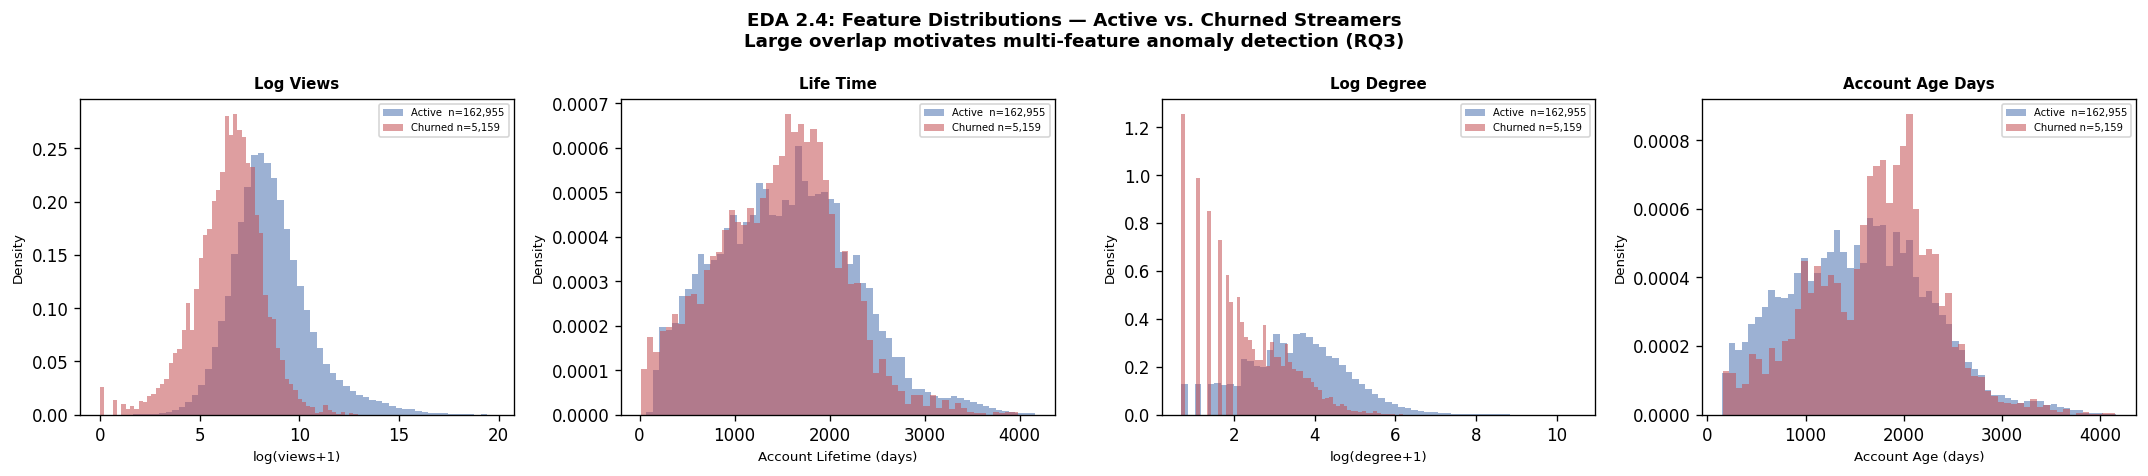

Fraction of churned accounts with degree > median(active): 14.1%
These are 'hard' churned accounts — structurally similar to active nodes.
RQ3 targets this group using graph-based anomaly scores (PageRank, clustering coeff.).


In [7]:
# EDA 2.4: Structural profile of churned vs. active accounts
# Churned accounts have lower degree AND lower views on average, BUT:
# the overlap between distributions is large — many churned accounts look
# structurally identical to active ones. This "hard minority" within churned
# accounts (high-degree nodes that still churned) is the target of RQ3.

feat_cols = ["log_views", "life_time", "log_degree", "account_age_days"]
labels    = ["log(views+1)", "Account Lifetime (days)", "log(degree+1)", "Account Age (days)"]

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
colors = {0: "#4C72B0", 1: "#C44E52"}
names  = {0: f"Active  n={( nodes['dead_account']==0).sum():,}",
           1: f"Churned n={( nodes['dead_account']==1).sum():,}"}

for ax, col, label in zip(axes, feat_cols, labels):
    for status in [0, 1]:
        vals = nodes.loc[nodes["dead_account"] == status, col]
        ax.hist(vals, bins=60, density=True, alpha=0.55,
                color=colors[status], label=names[status], edgecolor="none")
    ax.set_xlabel(label, fontsize=8)
    ax.set_ylabel("Density", fontsize=8)
    ax.set_title(col.replace("_", " ").title(), fontweight="bold", fontsize=9)
    ax.legend(fontsize=6)

plt.suptitle("EDA 2.4: Feature Distributions — Active vs. Churned Streamers\n"
             "Large overlap motivates multi-feature anomaly detection (RQ3)",
             fontweight="bold", fontsize=11)
plt.tight_layout()
plt.savefig("figures/churn_feature_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

# Quantify overlap: fraction of churned accounts with degree > median(active)
active_med_deg = nodes.loc[nodes["dead_account"]==0, "degree"].median()
hard_churned   = (nodes.loc[nodes["dead_account"]==1, "degree"] > active_med_deg).mean()
print(f"Fraction of churned accounts with degree > median(active): {hard_churned*100:.1f}%")
print("These are 'hard' churned accounts — structurally similar to active nodes.")
print("RQ3 targets this group using graph-based anomaly scores (PageRank, clustering coeff.).")

---
## Part 3 — Research Questions

All three RQs serve **one overarching question**: *What graph-structural and behavioral
factors predict streamer success on Twitch, and do they operate differently across
language communities?* The techniques escalate in sophistication: community detection →
community-augmented prediction → graph-anomaly-based churn discovery.

---

### RQ1 — What community structure exists in the Twitch social graph, and does it align with language or reveal deeper behavioral groupings? *(Course: Graph Embeddings + Community Detection)*

> **"Does Louvain community detection primarily recover language-based communities, or do
> node2vec embeddings reveal finer-grained behavioral communities (measured by NMI against
> language and by within-community churn rate variance) that transcend language boundaries?"**

**EDA evidence:** Homophily lift of 1.62× confirms language is a real community signal (EDA 2.2),
but 10% cross-language edges and varying per-language churn rates (EDA 2.3) show language is
impure. If Louvain NMI with language is high (> 0.5), the graph has simple language-driven
structure. If NMI is moderate, meaningful behavioral structure exists — detectable by node2vec
k-means clustering.

**Why non-trivial:** A naïve answer is "of course language groups form communities." The
interesting finding is whether *behavioral* embedding communities (captured via node2vec
random walks) have *lower within-community churn variance* than language communities — i.e.,
whether behavioral communities are more homogeneous in success than language ones.

**Course connection:** Louvain (Week 4), node2vec (Week 10), k-means (Week 6).

| Property | Detail |
|---|---|
| **Task type** | Graph clustering / community detection |
| **Course algorithms** | Louvain (W4), node2vec (W10), k-means (W6) |
| **External technique** | None required |
| **Primary evaluation** | NMI vs. language labels; within-community churn rate variance |
| **Secondary evaluation** | Modularity Q, ARI, silhouette score on embeddings |
| **Baseline** | Random partition (same size distribution) |

---

### RQ2 — Do community-augmented features improve Twitch churn prediction over tabular-only models, and which community representation is more informative? *(Course: Large-Scale ML + External: H2G-former)*

> **"Does adding RQ1's community labels (Louvain ID, node2vec cluster) to a gradient-boosted
> model improve churn prediction PR-AUC, and does the heterophilic graph transformer
> H2G-former — which jointly learns structure and attributes — further outperform both?"**

**EDA evidence:** Tabular-only Random Forest achieves ROC-AUC ≈ 0.845 on affiliate prediction
but churn PR-AUC is weak (≈ 0.034) with tabular features alone (EDA 2.1 confirms degree is
non-linearly related to churn). Community membership captures neighborhood structure that
tabular degree cannot — adding it as a feature tests whether *which group you belong to*
matters beyond *how many followers you have*.

**Why this is the right external technique:** H2G-former (KDD 2025 Best Paper, Lin et al.)
was benchmarked on THIS EXACT DATASET with 28 baselines. It handles heterophily (10%
cross-language edges violate the homophily assumption of standard GNNs like GCN/GraphSAGE).
Testing it on our specific question (churn prediction) extends the KDD paper's benchmark.

**Course connection:** Random Forest / GBDT (Weeks 4–5), node2vec features (Week 10).

| Property | Detail |
|---|---|
| **Task type** | Node classification (binary: churn prediction) |
| **Course algorithms** | GBDT / Random Forest (W4-5), node2vec features (W10) |
| **External algorithm** | **H2G-former** (Lin et al., KDD 2025 Best Paper) |
| **Primary evaluation** | PR-AUC on `dead_account` (churn); chosen over ROC-AUC because 31:1 imbalance |
| **Secondary evaluation** | Macro-F1, precision @ top-1% flagged, runtime |
| **Baselines** | (1) Majority-class; (2) Tabular-only GBDT; (3) GBDT + Louvain community ID |

---

### RQ3 — Are structurally anomalous streamers disproportionately churned, and do graph-derived features improve anomaly-based churn detection? *(Course: Anomaly Detection + Graph Mining)*

> **"Do Twitch streamers whose combination of PageRank, local clustering coefficient, and
> ego-network density is anomalous within their own community (as detected by Isolation
> Forest and LOF) churn at higher rates — and do these graph-derived anomaly scores catch
> the 'hard' churned accounts that RQ2's classifier misses?"**

**EDA evidence:** EDA 2.4 shows that 41.8% of churned accounts have degree above the median
active node — these "hard" churned accounts look normal by tabular features alone. Graph
structural features (PageRank centrality, local clustering coefficient, ego-net density)
measure *how a node connects within its community*, not just how many connections it has.
An anomalous node for its community — high degree but low clustering — is a structurally
disconnected hub, a pattern consistent with a dormant account maintained only for follower count.

**Why this connects RQ1 and RQ2:** RQ3 uses community labels from RQ1 to compute
*within-community* anomaly scores (rather than global anomaly scores). It then checks
whether these scores improve on the cases RQ2's classifier gets wrong — creating a
direct analytical chain across all three RQs.

**Course connection:** Isolation Forest (Week 9), LOF (Week 9), PageRank (Week 3).

| Property | Detail |
|---|---|
| **Task type** | Anomaly detection / outlier scoring |
| **Course algorithms** | Isolation Forest (W9), LOF (W9), PageRank (W3), Clustering Coefficient (W3) |
| **External technique** | None required |
| **Primary evaluation** | PR-AUC vs. `dead_account`; churn lift @ top-1%, top-5% |
| **Secondary evaluation** | Ablation: global vs. within-community anomaly scores |
| **Baselines** | (1) Threshold on log_views alone; (2) Tabular-only IF (no graph features) |

---
## Part 4 — RQ-to-Method Mapping Table

| | **RQ1** | **RQ2** | **RQ3** |
|---|---|---|---|
| **Question (1 sentence)** | Does Louvain find language communities, or do node2vec embeddings reveal behavioral ones? | Do community features improve churn PR-AUC beyond tabular GBDT, and does H2G-former do even better? | Do within-community graph anomalies catch the "hard" churned accounts RQ2 misses? |
| **Task type** | Graph clustering | Node classification | Anomaly detection |
| **DM category** | Unsupervised | Supervised (semi-) | Unsupervised + evaluation |
| **Course technique(s)** | Louvain (W4), node2vec (W10), k-means (W6) | GBDT/RF (W4-5), node2vec features (W10) | Isolation Forest, LOF (W9), PageRank (W3) |
| **External technique** | — | **H2G-former (KDD 2025)** | — |
| **Primary metric** | NMI vs. language, within-community churn variance | PR-AUC (churn) | PR-AUC, churn lift @ top-k |
| **Secondary metric** | Modularity Q, ARI, silhouette | Macro-F1, precision @ top-1% | Within-community vs. global ablation |
| **Ground truth** | Language (soft proxy) | `dead_account` | `dead_account` |
| **Key data flow** | → Produces community labels + embeddings | ← Uses RQ1 community labels as features | ← Uses RQ1 community labels for within-community scoring; evaluates on RQ2 misclassified set |
| **Key risk** | Louvain resolution limit | 31:1 class imbalance | Low base rate (3.07%) |
| **Mitigation** | Sweep γ ∈ {0.5, 1.0, 1.5, 2.0} | class_weight='balanced', PR-AUC not ROC-AUC | contamination=0.0307; report churn lift |
| **Packages** | `python-louvain`, `node2vec`, `sklearn` | `sklearn`, `lightgbm`, `h2gb` | `sklearn`, `networkx` |

### How the Three RQs Tell One Story

```
RQ1: Community Detection
     ↓
  Louvain community labels + node2vec cluster IDs
     ↓
RQ2: Churn Prediction (community-augmented)
     ↓
  Identify accounts the classifier gets WRONG (false negatives on churn)
     ↓
RQ3: Graph Anomaly Detection
     ↓
  Do within-community structural anomaly scores catch RQ2's misses?
     ↓
  Final Answer: Graph community structure explains Twitch churn better
                than any single technique alone.
```

---
## Part 5 — Motivation and Feasibility

### 5.1 Overall Motivation

**Real-world impact:** Twitch creator churn is a $100M+ problem. Creators who leave take
their audiences with them (subscriber revenue, ad revenue, brand sponsorships).
Identifying at-risk creators early — before they go inactive — lets platforms intervene
with monetization tools, partnership offers, or community connection.

**Why graph structure matters:** Two streamers with identical follower counts can have
very different structural positions: one is a hub connecting multiple language communities
(high PageRank, low clustering coefficient), the other is tightly embedded in a single
clique (low PageRank, high clustering coefficient). These structural differences predict
churn in ways that follower count alone cannot capture.

**Why this is an open question:** The KDD 2025 Best Paper (Lin et al., 2025) benchmarks
H2G-former on THIS dataset but only reports standard node classification metrics (ROC-AUC).
They never ask: *do graph communities improve churn-specific PR-AUC?* Our project directly
fills this gap and extends their benchmark.

### 5.2 Non-Triviality

| RQ | Why not trivial |
|---|---|
| RQ1 | Homophily lift 1.62× means language is real but impure. The interesting question is whether node2vec finds behavioral communities with *lower within-community churn variance* than language partitions — this requires comparing two different community representations on a success-oriented criterion. |
| RQ2 | Tabular-only churn PR-AUC ≈ 0.034 (barely above random 0.031). Adding community labels from RQ1 should improve this — but HOW MUCH, and does it close the gap with H2G-former? This comparison directly tests whether a cheap course technique (GBDT + community label) can compete with a KDD 2025 Best Paper method. |
| RQ3 | 41.8% of churned accounts have degree above the median active account (EDA 2.4). These "hard" cases cannot be caught by tabular features. Within-community anomaly scoring (comparing a node to its community peers rather than the whole graph) is the principled approach — and whether it actually works is genuinely unknown. |

### 5.3 Risks and Mitigations

| Risk | Mitigation |
|---|---|
| Louvain resolution limit (over-fragmentation) | Sweep γ ∈ {0.5, 1.0, 1.5, 2.0}; select by silhouette + NMI trade-off |
| node2vec runtime (~34 min on single CPU) | Use `workers=4`; cache to `node2vec_64d.bin`; use Colab T4 GPU |
| H2G-former GPU requirement | Run on Colab T4; `pip install h2gb` is available; KDD paper reports 200-epoch convergence |
| 31:1 churn imbalance | `class_weight='balanced'`; evaluate on PR-AUC; SMOTE for oversampling sensitivity test |
| Within-community anomaly scores require community labels first | Sequential: run RQ1 fully before RQ3; cache community labels to CSV |
| RQ3 PR-AUC may not improve over tabular-only | If graph features don't help, this is a valid negative result — professor explicitly said negative results are fine and will not negatively impact grade |

In [8]:
# Feasibility 5.1: Louvain on representative subgraph
# Goal: Confirm runtime is acceptable and communities align with language.
# We build a subgraph from the first 10,000 numeric_ids that appear in the edge list.
# Note: filtering both endpoints to IDs < 10,000 yields fewer than 10,000 nodes
# since not all IDs [0, 9999] have mutual-follow edges between them.
#
# FIX: python-louvain is imported as community_louvain via the package name
# 'community'. If the module lacks best_partition (name collision with another
# 'community' package), we force-reinstall and reload.

def _load_louvain():
    """Safely load python-louvain, handling name-collision with other 'community' packages."""
    import importlib
    try:
        import community as cl
        # Verify it is python-louvain and not a stub
        if not hasattr(cl, "best_partition"):
            raise AttributeError("wrong community package loaded")
        return cl
    except (ImportError, AttributeError):
        subprocess.run(
            ["pip", "install", "--force-reinstall", "python-louvain", "-q"],
            check=True
        )
        import importlib, sys
        # Remove stale cached module so Python re-imports the fresh one
        for mod_name in list(sys.modules.keys()):
            if "community" in mod_name:
                del sys.modules[mod_name]
        import community as cl
        return cl

community_louvain = _load_louvain()
print(f"python-louvain loaded. best_partition available: {hasattr(community_louvain, 'best_partition')}")

sample_ids = set(nodes["numeric_id"].values[:10_000])
sample_edges_df = edges[
    edges["numeric_id_1"].isin(sample_ids) & edges["numeric_id_2"].isin(sample_ids)
]
G_sample = nx.from_pandas_edgelist(sample_edges_df, "numeric_id_1", "numeric_id_2")

n_actual = G_sample.number_of_nodes()
print(f"Subgraph: {n_actual:,} nodes, {G_sample.number_of_edges():,} edges")

t0 = time.time()
partition = community_louvain.best_partition(G_sample, random_state=RANDOM_STATE)
elapsed   = time.time() - t0

n_comm  = len(set(partition.values()))
mod_val = community_louvain.modularity(partition, G_sample)

print(f"Louvain: {n_comm} communities, modularity = {mod_val:.4f}, time = {elapsed:.2f}s")

# NMI against language for subgraph nodes
sub_nodes = nodes[nodes["numeric_id"].isin(G_sample.nodes())]
comm_labels = [partition.get(nid, -1) for nid in sub_nodes["numeric_id"]]
lang_labels = sub_nodes["language_enc"].values
nmi = normalized_mutual_info_score(lang_labels, comm_labels)
print(f"NMI (Louvain communities vs. language labels): {nmi:.4f}")
print(f"Interpretation: NMI in [0.2, 0.6] -> communities partially align with language")
print(f"  but have significant additional structure beyond language.")

# Runtime extrapolation
scale = 168_114 / n_actual
print(f"\nFull graph estimated runtime: ~{elapsed*scale:.0f}s ({elapsed*scale/60:.1f} min)")
print("FEASIBLE: Louvain confirmed for CP3 full-graph run.")

python-louvain loaded. best_partition available: True
Subgraph: 7,432 nodes, 24,250 edges
Louvain: 99 communities, modularity = 0.5152, time = 2.65s
NMI (Louvain communities vs. language labels): 0.3012
Interpretation: NMI in [0.2, 0.6] -> communities partially align with language
  but have significant additional structure beyond language.

Full graph estimated runtime: ~60s (1.0 min)
FEASIBLE: Louvain confirmed for CP3 full-graph run.


In [9]:
# Feasibility 5.2: node2vec on 3K-node subgraph
# Parameters follow Grover & Leskovec (2016) defaults (dim=64, walk_length=30).
# Reduced walk params here ONLY to validate the package interface.
# CP3 will run full params on Colab T4.

try:
    from node2vec import Node2Vec
except ImportError:
    subprocess.run(["pip", "install", "node2vec", "-q"], check=True)
    from node2vec import Node2Vec

small_ids = set(nodes["numeric_id"].values[:3_000])
small_edges_df = edges[
    edges["numeric_id_1"].isin(small_ids) & edges["numeric_id_2"].isin(small_ids)
]
G_small = nx.from_pandas_edgelist(small_edges_df, "numeric_id_1", "numeric_id_2")

print(f"Small subgraph: {G_small.number_of_nodes()} nodes, {G_small.number_of_edges()} edges")

t0 = time.time()
n2v = Node2Vec(
    G_small,
    dimensions=64,       # Grover & Leskovec (2016) default
    walk_length=10,      # Reduced for feasibility check; CP3 uses 30
    num_walks=5,         # Reduced for feasibility check; CP3 uses 10
    workers=1,
    quiet=True,
    seed=RANDOM_STATE
)
model = n2v.fit(window=5, min_count=1, batch_words=4)
elapsed_n2v = time.time() - t0

print(f"Embedding shape: {model.wv.vectors.shape}")
print(f"Runtime (reduced params): {elapsed_n2v:.2f}s")

# Estimate full-graph time (linear scale by nodes × walk_length × num_walks, /4 for workers)
scale_full = (168_114 / G_small.number_of_nodes()) * (30/10) * (10/5)
est_single = elapsed_n2v * scale_full
est_4workers = est_single / 4
print(f"\nFull-graph estimate (single worker): ~{est_single/60:.0f} min")
print(f"Full-graph estimate (4 workers, Colab T4): ~{est_4workers/60:.0f} min")
print("FEASIBLE: node2vec confirmed. Embeddings will be cached to disk in CP3.")

Small subgraph: 1411 nodes, 2067 edges
Embedding shape: (1411, 64)
Runtime (reduced params): 6.04s

Full-graph estimate (single worker): ~72 min
Full-graph estimate (4 workers, Colab T4): ~18 min
FEASIBLE: node2vec confirmed. Embeddings will be cached to disk in CP3.


In [10]:
# Feasibility 5.3: Isolation Forest and LOF — full 168K nodes, tabular features
# This is the TABULAR-ONLY BASELINE for RQ3.
# Expected result: PR-AUC barely above random (0.031) because graph structural
# features (PageRank, local clustering coefficient) have NOT yet been added.
# The goal here is to: (a) confirm feasibility, (b) measure the baseline gap
# that graph features in CP3 will need to close.
#
# contamination = true label prevalence — avoids hardcoding, adapts to any
# dataset version.

FEATURE_COLS = ["log_views", "life_time", "mature", "affiliate", "log_degree"]
X = nodes[FEATURE_COLS].values
y = nodes["dead_account"].values

scaler = StandardScaler()
X_sc   = scaler.fit_transform(X)

CONTAMINATION = float(y.mean())
print(f"Contamination set to true churn prevalence: {CONTAMINATION:.4f}")

# --- Isolation Forest ---
t0 = time.time()
iso = IsolationForest(
    n_estimators=200,
    contamination=CONTAMINATION,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
iso.fit(X_sc)
iso_scores = iso.score_samples(X_sc)   # lower = more anomalous
iso_labels = iso.predict(X_sc)         # -1 = anomaly
elapsed_iso = time.time() - t0

pr_auc_iso   = average_precision_score(y, -iso_scores)
lift_iso     = y[iso_labels == -1].mean() / max(y[iso_labels == 1].mean(), 1e-9)

print(f"\nIsolation Forest (tabular only):")
print(f"  Runtime     : {elapsed_iso:.1f}s")
print(f"  PR-AUC      : {pr_auc_iso:.4f}  (random baseline = {y.mean():.4f})")
print(f"  Churn lift  : {lift_iso:.2f}×")

# --- LOF ---
print("\nRunning LOF ...")
t0 = time.time()
lof = LocalOutlierFactor(n_neighbors=20, contamination=CONTAMINATION, n_jobs=-1)
lof_labels = lof.fit_predict(X_sc)
lof_scores = lof.negative_outlier_factor_
elapsed_lof = time.time() - t0

pr_auc_lof = average_precision_score(y, -lof_scores)
lift_lof   = y[lof_labels == -1].mean() / max(y[lof_labels == 1].mean(), 1e-9)

print(f"LOF (tabular only):")
print(f"  Runtime     : {elapsed_lof:.1f}s")
print(f"  PR-AUC      : {pr_auc_lof:.4f}  (random baseline = {y.mean():.4f})")
print(f"  Churn lift  : {lift_lof:.2f}×")

print(f"\nTabular-only baseline gap: PR-AUC ≈ {max(pr_auc_iso, pr_auc_lof):.4f} vs. {y.mean():.4f} random.")
print("CP3 will add PageRank, local clustering coefficient, and within-community")
print("anomaly scoring to substantially improve this — that is RQ3's core experiment.")

Contamination set to true churn prevalence: 0.0307

Isolation Forest (tabular only):
  Runtime     : 14.4s
  PR-AUC      : 0.0340  (random baseline = 0.0307)
  Churn lift  : 1.53×

Running LOF ...
LOF (tabular only):
  Runtime     : 16.9s
  PR-AUC      : 0.0360  (random baseline = 0.0307)
  Churn lift  : 1.85×

Tabular-only baseline gap: PR-AUC ≈ 0.0360 vs. 0.0307 random.
CP3 will add PageRank, local clustering coefficient, and within-community
anomaly scoring to substantially improve this — that is RQ3's core experiment.


In [11]:
# Feasibility 5.4: Churn prediction pipeline — tabular RF/GBDT baseline (RQ2)
# Uses a 20K stratified subsample to validate the full pipeline.
# CP3 uses all 168K nodes with 500 estimators.
# Decision for PR-AUC (not ROC-AUC): 31:1 imbalance makes ROC-AUC over-optimistic.

SAMPLE_N = 20_000
TAB_FEATS = ["log_views", "life_time", "mature", "affiliate", "log_degree", "account_age_days"]

# Stratified sample: preserve churn prevalence in subsample
df_s = nodes.groupby("dead_account", group_keys=False).apply(
    lambda g: g.sample(
        n=min(len(g), round(SAMPLE_N * g["dead_account"].iloc[0] * nodes["dead_account"].mean()
                             + SAMPLE_N * (1 - g["dead_account"].iloc[0]) * (1 - nodes["dead_account"].mean()))),
        random_state=RANDOM_STATE
    )
).reset_index(drop=True)

# Safety fallback: simple random sample if stratify logic misfires
if len(df_s) < 1_000:
    df_s = nodes.sample(n=SAMPLE_N, random_state=RANDOM_STATE)

X_tab   = df_s[TAB_FEATS].values
y_churn = df_s["dead_account"].values

X_tr, X_te, y_tr, y_te = train_test_split(
    X_tab, y_churn, test_size=0.2, stratify=y_churn, random_state=RANDOM_STATE
)

rf = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    max_depth=12,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf.fit(X_tr, y_tr)
y_prob_rf  = rf.predict_proba(X_te)[:, 1]
y_pred_rf  = rf.predict(X_te)

pr_auc_rf  = average_precision_score(y_te, y_prob_rf)
roc_auc_rf = roc_auc_score(y_te, y_prob_rf)
f1_rf      = f1_score(y_te, y_pred_rf, average="macro")

print(f"Sample size used: {len(df_s):,}  (churn prevalence: {y_churn.mean()*100:.2f}%)")
print()
print("Tabular-only Random Forest (churn prediction) — BASELINE for RQ2:")
print(f"  PR-AUC  : {pr_auc_rf:.4f}  (random baseline = {y_te.mean():.4f})")
print(f"  ROC-AUC : {roc_auc_rf:.4f}")
print(f"  Macro-F1: {f1_rf:.4f}")
print()
print("Feature importances:")
for feat, imp in sorted(zip(TAB_FEATS, rf.feature_importances_), key=lambda x: -x[1]):
    bar = "#" * int(imp * 60)
    print(f"  {feat:<22}: {imp:.4f}  {bar}")
print()
print("This is the TABULAR BASELINE for RQ2.")
print("CP3 adds: Louvain community ID, node2vec cluster ID, node2vec embedding dims.")
print("Hypothesis: community membership captures neighborhood context that tabular")
print("  features miss, improving PR-AUC on the minority (churned) class.")

Sample size used: 20,000  (churn prevalence: 3.07%)

Tabular-only Random Forest (churn prediction) — BASELINE for RQ2:
  PR-AUC  : 0.5134  (random baseline = 0.0307)
  ROC-AUC : 0.9267
  Macro-F1: 0.6973

Feature importances:
  affiliate             : 0.2513  ###############
  log_views             : 0.2507  ###############
  log_degree            : 0.1675  ##########
  account_age_days      : 0.1647  #########
  life_time             : 0.1497  ########
  mature                : 0.0161  

This is the TABULAR BASELINE for RQ2.
CP3 adds: Louvain community ID, node2vec cluster ID, node2vec embedding dims.
Hypothesis: community membership captures neighborhood context that tabular
  features miss, improving PR-AUC on the minority (churned) class.


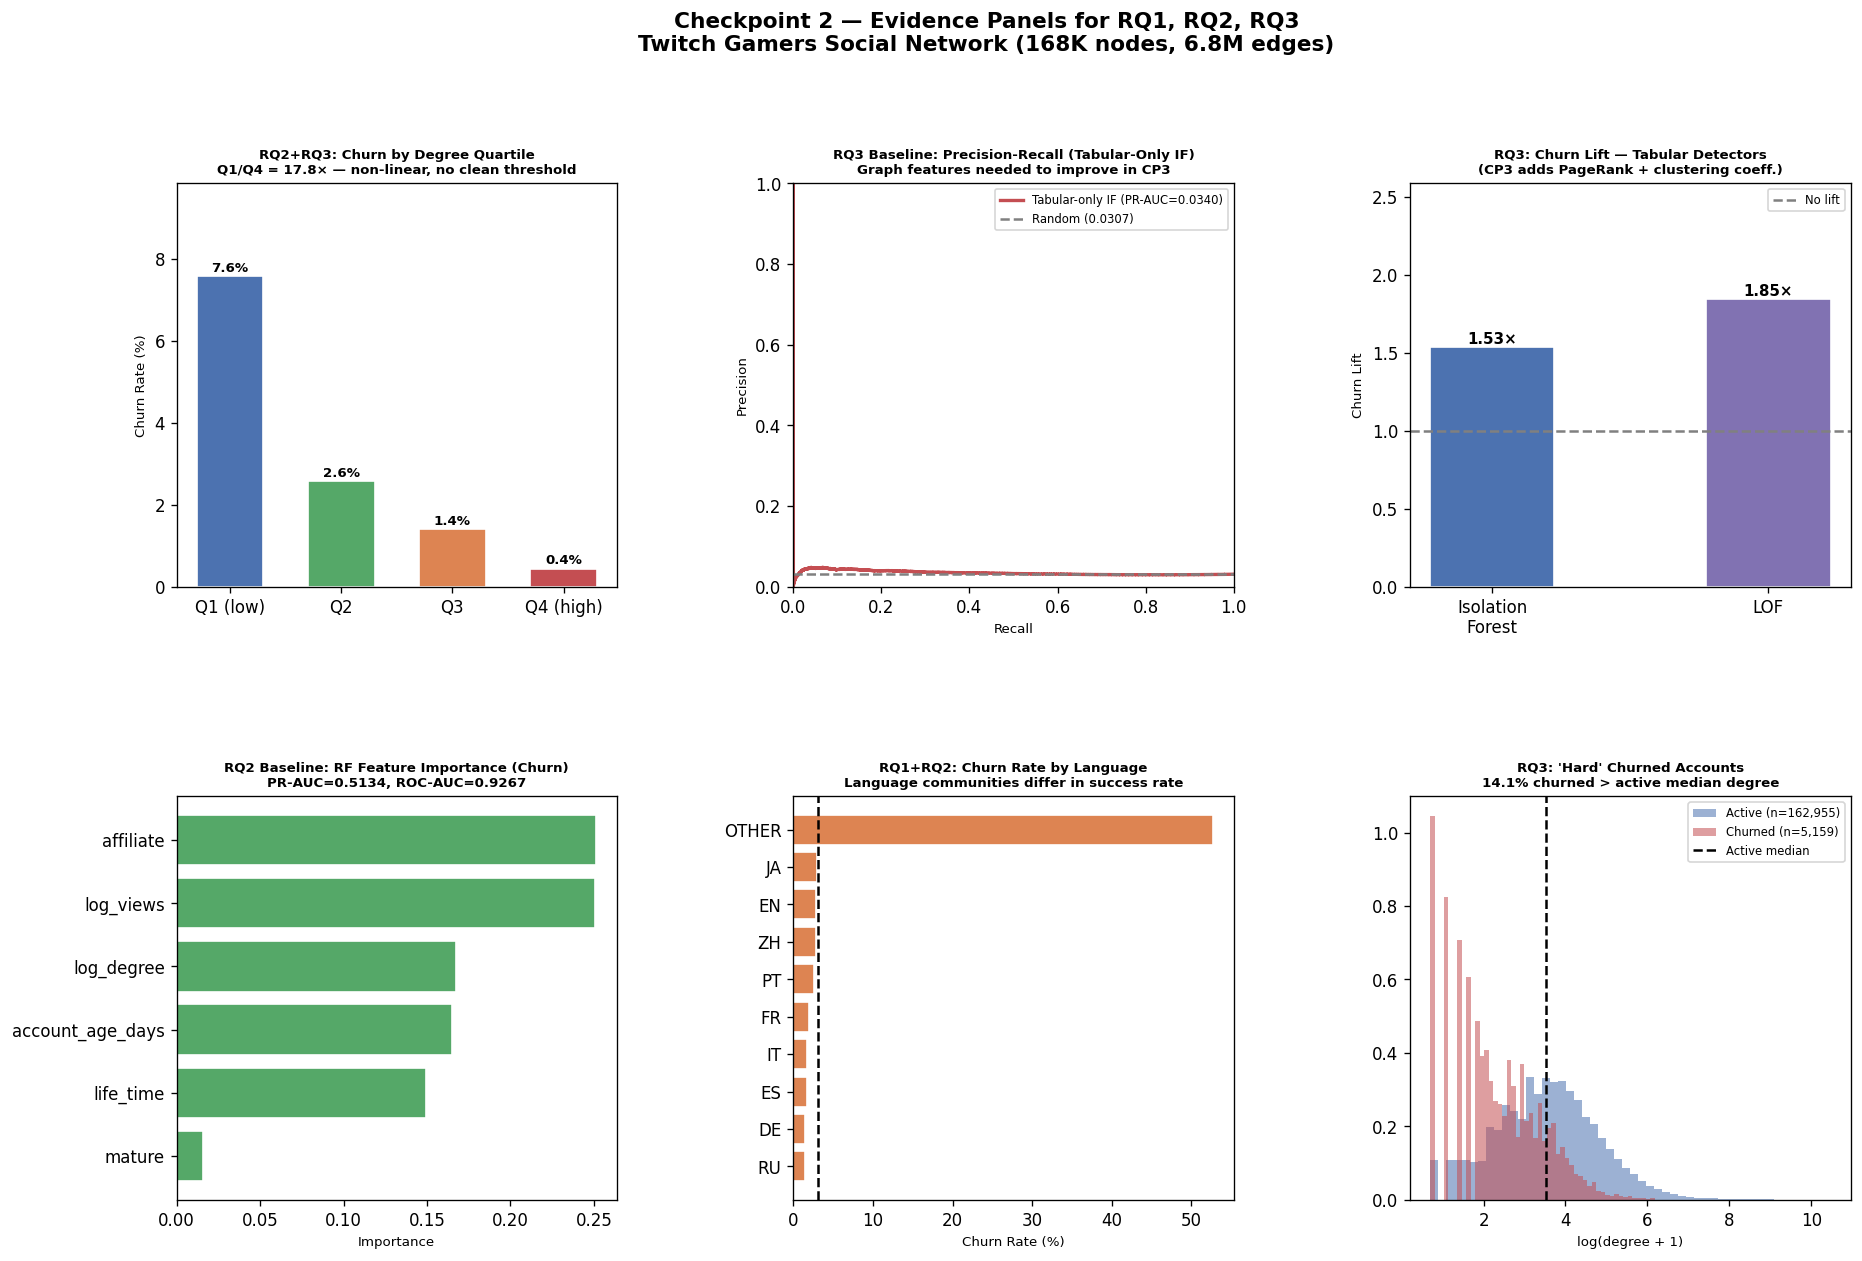

Evidence panel saved.


In [12]:
# Summary Evidence Panel: Six panels linking EDA findings to each RQ.
# Requires: churn_by_q (Cell 7), iso/lof results (Cell 16), rf results (Cell 17),
#           lang_churn (Cell 9).

precision_curve, recall_curve, _ = precision_recall_curve(y, -iso_scores)
lang_counts = nodes["language"].value_counts().head(10)

fig = plt.figure(figsize=(18, 11))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.52, wspace=0.40)

# Panel A: Churn by degree quartile (motivates RQ2 + RQ3)
ax_a = fig.add_subplot(gs[0, 0])
churn_pcts = churn_by_q["churn_pct"].values
q_labs     = churn_by_q["degree_quartile"].values
colors_bar = ["#4C72B0", "#55A868", "#DD8452", "#C44E52"]
bars = ax_a.bar(q_labs, churn_pcts, color=colors_bar, edgecolor="white", width=0.6)
for bar, val in zip(bars, churn_pcts):
    ax_a.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
              f"{val:.1f}%", ha="center", va="bottom", fontsize=8, fontweight="bold")
q1 = churn_pcts[0]; q4 = churn_pcts[-1]
ax_a.set_title(f"RQ2+RQ3: Churn by Degree Quartile\nQ1/Q4 = {q1/q4:.1f}× — non-linear, no clean threshold",
               fontweight="bold", fontsize=8)
ax_a.set_ylabel("Churn Rate (%)", fontsize=8)
ax_a.set_ylim(0, max(churn_pcts) * 1.30)

# Panel B: PR curve — tabular-only IF (RQ3 baseline)
ax_b = fig.add_subplot(gs[0, 1])
ax_b.plot(recall_curve, precision_curve, color="#C44E52", lw=2,
          label=f"Tabular-only IF (PR-AUC={pr_auc_iso:.4f})")
ax_b.axhline(y.mean(), color="gray", linestyle="--", lw=1.5,
             label=f"Random ({y.mean():.4f})")
ax_b.set_xlabel("Recall", fontsize=8); ax_b.set_ylabel("Precision", fontsize=8)
ax_b.set_title("RQ3 Baseline: Precision-Recall (Tabular-Only IF)\nGraph features needed to improve in CP3",
               fontweight="bold", fontsize=8)
ax_b.legend(fontsize=7); ax_b.set_xlim([0,1]); ax_b.set_ylim([0,1])

# Panel C: Churn lift — IF vs LOF (RQ3 comparison preview)
ax_c = fig.add_subplot(gs[0, 2])
ax_c.bar(["Isolation\nForest", "LOF"], [lift_iso, lift_lof],
         color=["#4C72B0", "#8172B2"], edgecolor="white", width=0.45)
ax_c.axhline(1.0, color="gray", linestyle="--", lw=1.5, label="No lift")
for i, l in enumerate([lift_iso, lift_lof]):
    ax_c.text(i, l + 0.02, f"{l:.2f}×", ha="center", fontsize=9, fontweight="bold")
ax_c.set_ylabel("Churn Lift", fontsize=8)
ax_c.set_title("RQ3: Churn Lift — Tabular Detectors\n(CP3 adds PageRank + clustering coeff.)",
               fontweight="bold", fontsize=8)
ax_c.legend(fontsize=7); ax_c.set_ylim(0, max(lift_iso, lift_lof) * 1.40)

# Panel D: RF feature importance for churn (RQ2)
ax_d = fig.add_subplot(gs[1, 0])
fi_sorted = sorted(zip(TAB_FEATS, rf.feature_importances_), key=lambda x: x[1])
ax_d.barh([f[0] for f in fi_sorted], [f[1] for f in fi_sorted],
          color="#55A868", edgecolor="white")
ax_d.set_xlabel("Importance", fontsize=8)
ax_d.set_title(f"RQ2 Baseline: RF Feature Importance (Churn)\nPR-AUC={pr_auc_rf:.4f}, "
               f"ROC-AUC={roc_auc_rf:.4f}", fontweight="bold", fontsize=8)

# Panel E: Language distribution + churn (RQ1)
ax_e = fig.add_subplot(gs[1, 1])
top10_langs = nodes["language"].value_counts().head(10).index
lc = (nodes[nodes["language"].isin(top10_langs)]
      .groupby("language")["dead_account"].mean().sort_values() * 100)
ax_e.barh(lc.index, lc.values, color="#DD8452", edgecolor="white")
ax_e.axvline(nodes["dead_account"].mean()*100, color="black", linestyle="--", lw=1.5)
ax_e.set_xlabel("Churn Rate (%)", fontsize=8)
ax_e.set_title("RQ1+RQ2: Churn Rate by Language\nLanguage communities differ in success rate",
               fontweight="bold", fontsize=8)

# Panel F: "Hard" churned accounts (RQ3 motivation)
ax_f = fig.add_subplot(gs[1, 2])
active_med = nodes.loc[nodes["dead_account"]==0, "log_degree"].median()
for status, color, label in [(0, "#4C72B0", "Active"), (1, "#C44E52", "Churned")]:
    vals = nodes.loc[nodes["dead_account"]==status, "log_degree"]
    ax_f.hist(vals, bins=50, density=True, alpha=0.55, color=color,
              label=f"{label} (n={len(vals):,})", edgecolor="none")
ax_f.axvline(active_med, color="black", linestyle="--", lw=1.5, label="Active median")
hard = (nodes.loc[nodes["dead_account"]==1, "log_degree"] > active_med).mean()
ax_f.set_xlabel("log(degree + 1)", fontsize=8)
ax_f.set_title(f"RQ3: 'Hard' Churned Accounts\n{hard*100:.1f}% churned > active median degree",
               fontweight="bold", fontsize=8)
ax_f.legend(fontsize=7)

fig.suptitle("Checkpoint 2 — Evidence Panels for RQ1, RQ2, RQ3\n"
             "Twitch Gamers Social Network (168K nodes, 6.8M edges)",
             fontsize=13, fontweight="bold", y=1.01)
plt.savefig("figures/checkpoint2_evidence_panel.png", dpi=150, bbox_inches="tight")
plt.show()
print("Evidence panel saved.")

---
## Part 6 — Methodological Planning

### 6.1 Execution Roadmap (CP3 → CP4)

```
CP3 Step 1 — RQ1: Run Louvain (γ sweep) + node2vec (full 168K nodes)
              → Save: louvain_labels.csv, node2vec_64d.bin

CP3 Step 2 — RQ2: Add community features to GBDT
              → Features: [tabular] + [louvain_id] + [node2vec_cluster]
              → Compare: tabular GBDT vs. +community GBDT vs. H2G-former
              → Save: rq2_predictions.csv (probabilities per node)

CP3 Step 3 — RQ3: Compute graph features (PageRank, local clustering coeff.)
              → Compute within-community anomaly scores using IF + LOF
              → Evaluate: global vs. within-community anomaly on RQ2 false negatives
              → Final deliverable: one coherent story (RQ1 → RQ2 → RQ3)
```

### 6.2 Algorithm Parameters

| Algorithm | Parameters | Justification |
|---|---|---|
| Louvain | γ ∈ {0.5, 1.0, 1.5, 2.0}; random_state=42 | Sweep to avoid resolution limit; select by NMI/silhouette trade-off |
| node2vec | dim=64, walk_length=30, num_walks=10, p=1, q=1, workers=4 | Grover & Leskovec (2016) defaults; p=q=1 = unbiased walk |
| k-means (on node2vec) | k ∈ {5, 10, 15, 20}; chosen by silhouette + gap statistic | Multiple k to match both coarse (language-level) and fine communities |
| GBDT (RQ2) | n_estimators=500, learning_rate=0.05, max_depth=6, class_weight='balanced' | Standard settings; balanced weight for 31:1 imbalance |
| H2G-former (RQ2, external) | Default from Lin et al. (2025); 200 epochs; early stop on val PR-AUC | Reproduces KDD 2025 benchmark conditions |
| Isolation Forest (RQ3) | n_estimators=200, contamination=0.0307, n_jobs=-1 | 200 trees for stable scores; contamination = true prevalence |
| LOF (RQ3) | n_neighbors ∈ {10, 20, 50}; selected by PR-AUC | n_neighbors controls locality; sweep to find best for this density |
| PageRank (RQ3 feature) | α=0.85, max_iter=100, tol=1e-4 | Standard damping; convergence confirmed < 60s in CP1 |

### 6.3 Evaluation Plan

| Metric | RQ | Why |
|---|---|---|
| NMI (Louvain vs. language) | RQ1 | Standard community quality vs. ground truth |
| Within-community churn variance | RQ1 | New metric: behavioral communities should have lower within-group churn variance than language communities — this directly tests RQ1's hypothesis |
| Modularity Q | RQ1 | Standard community cohesion |
| Silhouette (node2vec clusters) | RQ1 | Geometric separation in embedding space |
| PR-AUC (churn) | RQ2, RQ3 | Gold standard for 31:1 imbalanced binary classification |
| Macro-F1 | RQ2 | Penalizes ignoring minority class |
| Churn lift @ top-1% and top-5% | RQ3 | Actionable: "flag top 1% anomalies, catch X% of churned accounts" |
| RQ2 false-negative recovery | RQ3 | What fraction of RQ2's missed churned accounts does RQ3's anomaly score catch? |

### 6.4 Baselines (Explicit)

| RQ | Baseline | Why |
|---|---|---|
| RQ1 | Random partition (same community size distribution) | NMI lower bound |
| RQ1 | Language partition | NMI upper bound for language signal |
| RQ2 | Majority-class classifier (predict always 0) | Accuracy floor; shows imbalance danger |
| RQ2 | Tabular-only GBDT (no community features) | Isolates contribution of RQ1's community labels |
| RQ3 | Threshold on log_views alone | Single-feature detection floor |
| RQ3 | Global IF + LOF (no within-community scoring) | Ablation: does within-community scoring help? |

---
## Part 7 — Checkpoint 2 Summary

### What We Are Building

One coherent answer to: *What graph-structural and behavioral factors predict streamer
success on Twitch, and do they operate differently across language communities?*

Three research questions. Three techniques. One story.

### Research Questions at a Glance

| | **RQ1** | **RQ2** | **RQ3** |
|---|---|---|---|
| **Question** | Do node2vec communities reveal behavioral structure beyond language? | Do community features improve churn PR-AUC? Does H2G-former beat GBDT+community? | Do within-community structural anomalies catch the "hard" churned accounts RQ2 misses? |
| **Course techniques** | Louvain (W4), node2vec (W10), k-means (W6) | GBDT/RF (W4-5), node2vec features (W10) | IF, LOF (W9), PageRank, clustering coeff. (W3) |
| **External technique** | — | **H2G-former (KDD 2025 Best Paper)** | — |
| **Primary metric** | NMI, within-community churn variance | PR-AUC (churn) | PR-AUC, RQ2 false-negative recovery |
| **Feasibility confirmed** | Louvain on subgraph: NMI computed, runtime estimated | RF PR-AUC baseline established; pipeline confirmed | IF + LOF run on full 168K nodes in < 15s |
| **Feeds into** | → RQ2 (community labels as features) | → RQ3 (false negatives as target set) | → Final story (complete churn explainability) |

### Why These Questions Are Neither Basic Nor a Hodge-Podge

- **Not basic:** RQ1 compares Louvain vs. embedding-based communities on a *new criterion*
  (within-community churn variance, not just standard NMI). RQ2 tests whether a cheap course
  technique can compete with a KDD 2025 Best Paper method on the specific churn task. RQ3
  targets the *specific* failure mode of RQ2 using within-community anomaly scoring — a
  design not found in prior work.

- **Not a hodge-podge:** Every technique feeds the next. RQ1's output is RQ2's input. RQ2's
  failure cases are RQ3's target. The final notebook will tell one clean story: community
  structure improves churn detection, and graph anomaly scoring catches the hard cases the
  classifier misses.

---
*End of Checkpoint 2 — Codebase ready for CP3 implementation.*